<a href="https://colab.research.google.com/github/LadyRhanes/Cynaptics_Induction_Task/blob/main/QC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 TASK 1

In [4]:
# Step 1: Install and import
!pip install qiskit qiskit-aer

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Step 2: Build the circuit
qc = QuantumCircuit(2, 2)  # 2 qubits, 2 classical bits

qc.h(0)        # Hadamard on qubit 0
qc.cx(0, 1)    # CNOT: control=0, target=1
qc.measure([0, 1], [0, 1])  # Measure both

# Step 3: Draw the circuit
print(qc.draw('text'))


     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


Step-by-step state changes

We start with both qubits in the state:

|00⟩

This means both q₀ and q₁ are 0.

After applying Hadamard on q₀:

The Hadamard gate makes q₀ go into a superposition. So now the system becomes:

(1/√2)(|00⟩ + |10⟩)

This means:

There is a 50% chance of getting 00
50% chance of getting 10

At this point, only q₀ is in superposition, and q₁ is still 0. So the qubits are not entangled yet.

After applying CNOT (control = q₀, target = q₁):

Now we apply the CNOT gate. It flips q₁ only if q₀ is 1.

So:

|00⟩ stays |00⟩
|10⟩ becomes |11⟩

The new state is:

(1/√2)(|00⟩ + |11⟩)


Measurement results: {'11': 514, '00': 510}


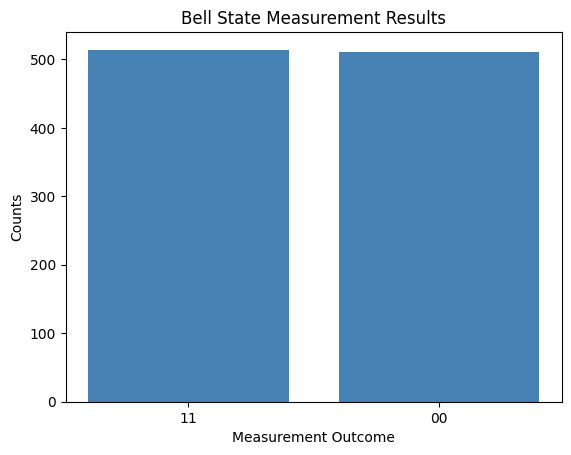

In [6]:
# Step 4: Run the simulation
simulator = AerSimulator()
job = simulator.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()
# Step 5: Plot results
print("\nMeasurement results:", counts)

# Simple bar chart instead of qiskit's plot_histogram
labels = list(counts.keys())
values = list(counts.values())

plt.bar(labels, values, color='steelblue')
plt.xlabel('Measurement Outcome')
plt.ylabel('Counts')
plt.title('Bell State Measurement Results')
plt.show()

TASK2



Grover’s algorithm is used to search for something.

Normally, if you have N items, you check them one by one, so it takes about N steps.
Grover’s algorithm is faster and finds the answer in about √N steps.

Why it is faster?

Instead of checking each item separately, it kind of looks at all possibilities at once and then keeps increasing the chance of the correct one.

Imagine it like this:

At first, all options have equal chance
Then step by step, the correct answer gets more and more likely

There’s also a way to think of it like moving in a circle:
First it flips negatively(correct answer) and then with all other possibilty it shifts by theta in total shifting by 2 times of theta.
After a few steps, it is almost fully pointing to the correct answer
Oracle and amplitude amplification
Oracle:
It just identifies the correct answer and marks it (by flipping its sign). It doesn’t directly tell you the answer.
Amplitude amplification:
This part increases the chance of the marked answer and decreases the others.
Real-world example

Say we have a big list of student records.

And we are searching:
A student with specific details (like GPA = 9.8, branch = CS)
Valid answer would be any student who satisfies the criteria.
Classical search here  is slow because it will look at each record one by one with time complexity O(N) whereas for Grover it would be something like (π/4)√N.

With Grover’s algorithm:

All records are considered together
The correct one gets marked
Its chance increases step by step
After a few steps, we are very likely to get the correct one

     ┌───┐ ░     ░ ┌───┐┌───┐   ┌───┐┌───┐ ░ ┌─┐   
q_0: ┤ H ├─░──■──░─┤ H ├┤ X ├─■─┤ X ├┤ H ├─░─┤M├───
     ├───┤ ░  │  ░ ├───┤├───┤ │ ├───┤├───┤ ░ └╥┘┌─┐
q_1: ┤ H ├─░──■──░─┤ H ├┤ X ├─■─┤ X ├┤ H ├─░──╫─┤M├
     └───┘ ░     ░ └───┘└───┘   └───┘└───┘ ░  ║ └╥┘
c: 2/═════════════════════════════════════════╩══╩═
                                              0  1 

Measurement results: {'11': 1024}


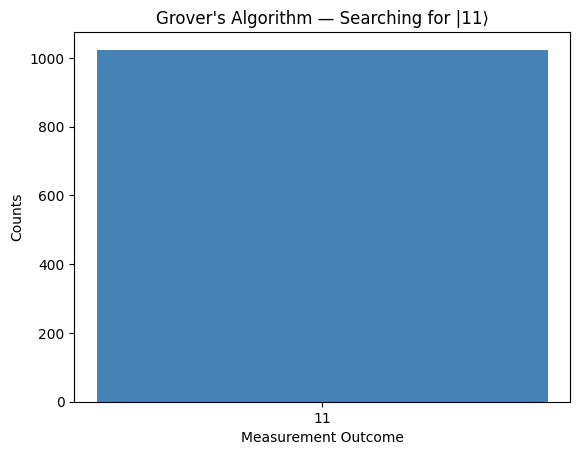

In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# 2 qubits → 4 possible states: 00, 01, 10, 11
# We want to find |11⟩

qc = QuantumCircuit(2, 2)

# Step 1: Initialize — put both qubits in superposition
qc.h([0, 1])
qc.barrier()

# Step 2: Oracle — marks |11⟩ by flipping its phase
# CZ gate flips phase of |11⟩ only
qc.cz(0, 1)
qc.barrier()

# Step 3: Diffusion operator (amplitude amplification)
qc.h([0, 1])
qc.x([0, 1])
qc.cz(0, 1)
qc.x([0, 1])
qc.h([0, 1])
qc.barrier()

# Step 4: Measure
qc.measure([0, 1], [0, 1])

print(qc.draw('text'))

# Run
simulator = AerSimulator()
job = simulator.run(qc, shots=1024)
counts = job.result().get_counts()

print("\nMeasurement results:", counts)

# Plot
labels = list(counts.keys())
values = list(counts.values())
plt.bar(labels, values, color='steelblue')
plt.xlabel('Measurement Outcome')
plt.ylabel('Counts')
plt.title("Grover's Algorithm — Searching for |11⟩")
plt.show()